# Netflix Analysis

## Objective
The objective of this analysis is to compare the distribution of movies and TV shows on Netflix and examine how content 
additions have evolved over the years. 
It also aims to identify the top contributing countries and analyze the distribution of content ratings to understand overall 
content trends on the platform.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

### Import Dataset

In [4]:
df = pd.read_csv("D:/Fusion_Project/netflix_titles.csv")

In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [7]:
df.shape

(8807, 12)

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Observation
1) The dataset contains multiple numerical and categorical columns.
2) Some columns have missing values which need to be handled.
3) A few duplicate rows are present and will be removed.
4) Numerical columns show variation in values, indicating possible trends and outliers.

In [10]:
df.isna().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

### Data Cleaning
1) Duplicate rows were removed to avoid redundancy.
2) Missing values in categorical columns were replaced with meaningful placeholders.
3) The 'date_added' column was converted into datetime format for time-based analysis.

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(8807, 12)

In [13]:
df['director'] = df['director'].fillna('Unknown_Director')
df['country'] = df['country'].fillna('Unknown_Country')
df['cast'] =df['cast'].fillna('Unknown_Cast')
df['rating'] = df['rating'].fillna('Not Rated')

In [14]:
df.isna().sum().sort_values(ascending=False)

date_added      10
duration         3
show_id          0
type             0
title            0
director         0
cast             0
country          0
release_year     0
rating           0
listed_in        0
description      0
dtype: int64

## Feature Engineering 
1) Extracted year and month from the 'date_added' column to analyze trends over time.
2) Converted duration into numeric format for better analysis.
3) Created a binary column to distinguish between movies and TV shows.


In [15]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

In [16]:
df['Year'] = df['date_added'].dt.year
df['Month'] = df['date_added'].dt.month

In [17]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['is_movie'] = df['type'].apply(lambda x: 1 if x == 'Movie' else 0)

## Data Analysis
1) Compared the number of movies and TV shows.
2) Analyzed how content was added over the years.
3) Identified top contributing countries.
4) Studied distribution of content ratings.


In [36]:
df['type'].value_counts()

type
Movie      6131
Tv Show    2676
Name: count, dtype: int64

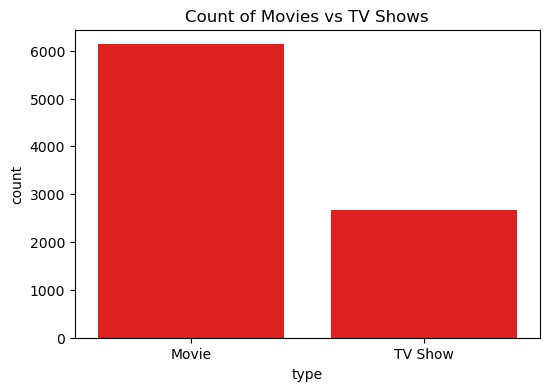

In [21]:
# Compared the number of movies and TV shows.
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='type',color='Red')
plt.title('Count of Movies vs TV Shows')
plt.show()

In [41]:
df.groupby('Year')['show_id'].count()

Year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: show_id, dtype: int64

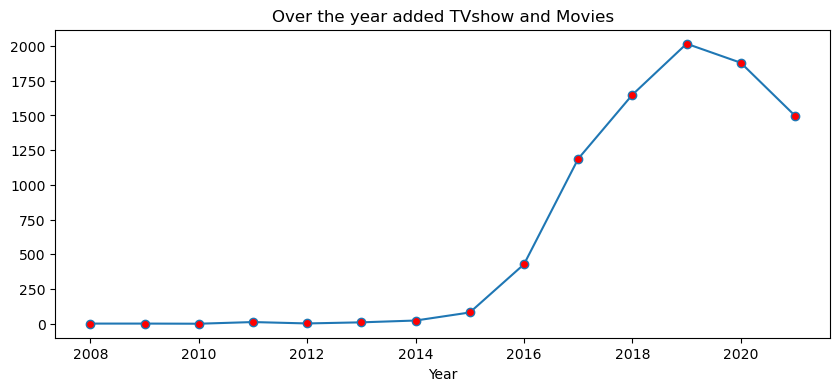

In [22]:
# Analyzed how content was added over the years
plt.figure(figsize=(10,4))
df.groupby('Year')['show_id'].count().plot(kind="line",marker='o',markerfacecolor='Red')
plt.title("Over the year added TVshow and Movies")
plt.show()

In [43]:
print(df['country'].value_counts().head(10))

country
United States      2818
India               972
Unknown_Country     831
United Kingdom      419
Japan               245
South Korea         199
Canada              181
Spain               145
France              124
Mexico              110
Name: count, dtype: int64


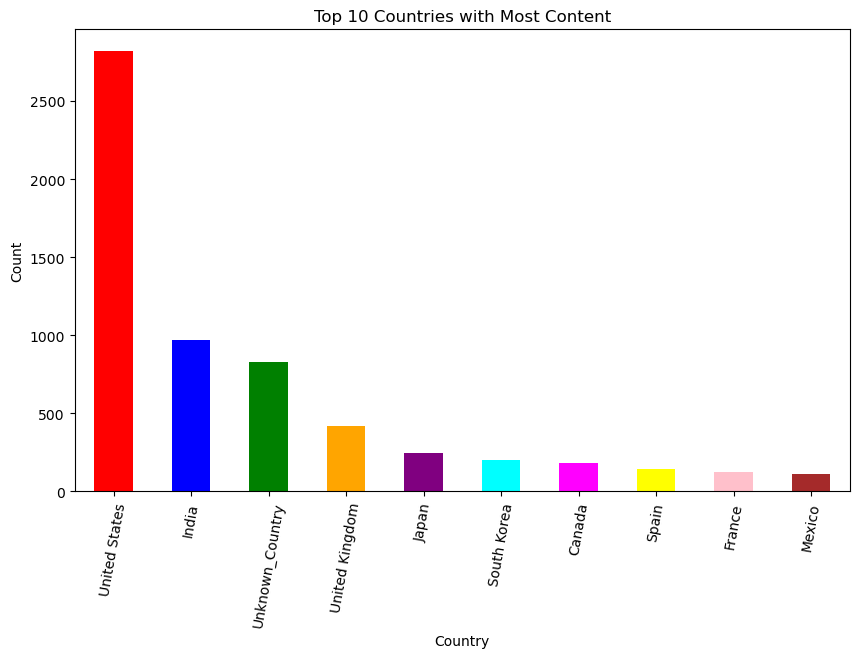

In [45]:
# Identified top 10 contributing countries.
plt.figure(figsize=(10,6))
df['country'].value_counts().head(10).plot(kind='bar', color=['red', 'blue', 'green', 'orange', 'purple','cyan', 'magenta', 'yellow', 'pink', 'brown'])
plt.title("Top 10 Countries with Most Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=80)
plt.show()

In [44]:
print(df['rating'].value_counts())

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64


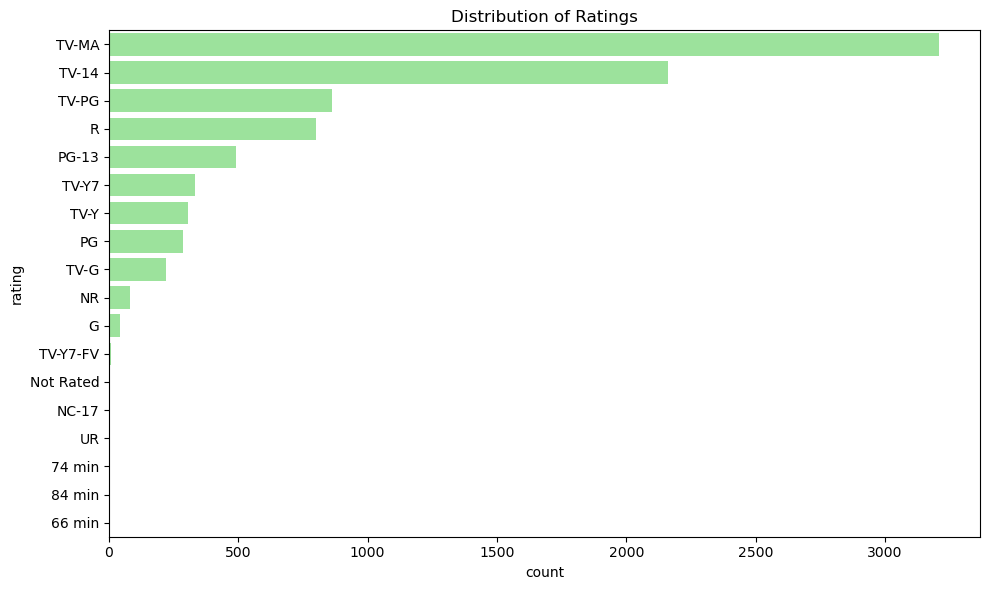

In [24]:
# Studied distribution of content ratings.
plt.figure(figsize=(10,6))
sns.countplot(data=df,y='rating',order=df['rating'].value_counts().index,color="lightgreen")
plt.title("Distribution of Ratings")
plt.tight_layout()
plt.show()

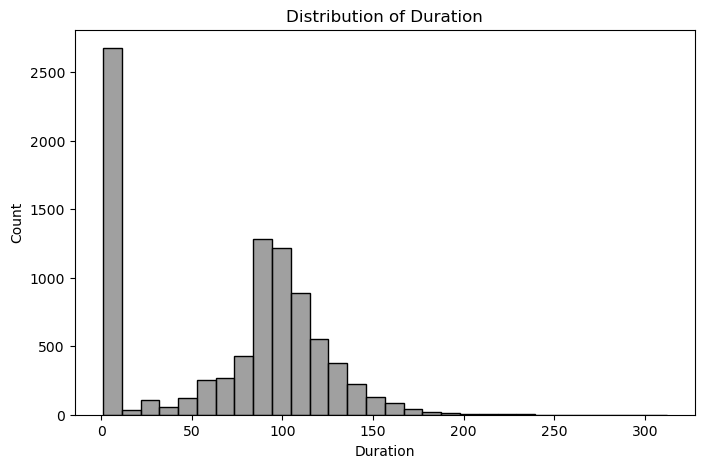

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['duration_num'].dropna(), bins=30,color="Grey")
plt.title("Distribution of Duration")
plt.xlabel("Duration")
plt.show()

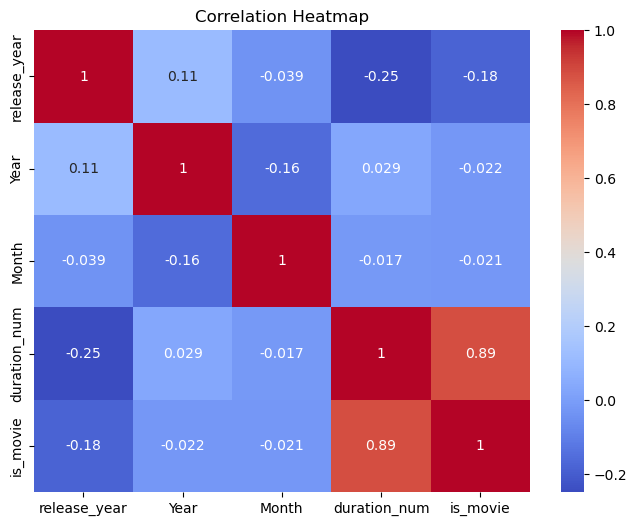

In [46]:
# Finding Correlation in between dataset on numeric columns
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Conclusion (Insights)
1) Movies are more common than TV shows on Netflix.
2) Content addition increased significantly after 2015.
3) The United States contributes the most content.
4) TV-MA is one of the most common ratings.
5) Most movies have durations between 80–120 minutes.
6) Some countries contribute very little content.
7) There is a steady growth in content over time.